# Real data: roughness and hedging on S&P 500 and VIX

Daily closes of the S&P 500 (`^GSPC`) and the VIX (`^VIX`), 2010 to 2025, downloaded from a public Yahoo Finance chart endpoint and stored under `data/`. Three stages: **before** (what the series look like), **during** (the roughness estimate with a synthetic calibration), **after** (hedge replay on real price windows).

> **Scope and labels.** The VIX is a *proxy* for the spot volatility level (30-day implied volatility, not instantaneous variance). Hedge replay uses realised S&P 500 windows with option payoffs computed from the strike, no market option prices; costs are an assumed 10 bp. Learned hedgers are trained on simulated rough Bergomi paths only and evaluated here out of sample. Nothing here is investment advice.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import json, math, numpy as np, pandas as pd, matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display
import io
from rough_hedge.rbergomi import simulate_rbergomi
from rough_hedge.roughness import estimate_hurst
from rough_hedge.experiment import run_comparison, compare_arms
from rough_hedge.risk import cvar_tail_mean
from rough_hedge.stats import holm
from rough_hedge.hedging import hedging_pnl
PAL = ['#0072B2', '#E69F00', '#009E73', '#D55E00', '#56B4E9', '#CC79A7', '#6B6B6B']
plt.rcParams.update({'figure.facecolor': 'white', 'axes.grid': True, 'grid.alpha': .25,
                     'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 10})
def show(fig):
    b = io.BytesIO(); fig.savefig(b, format='png', dpi=100, facecolor='white', bbox_inches='tight'); plt.close(fig)
    display(Image(b.getvalue()))
CFG = dict(n_seeds=2, seed=2026, n_train=512, n_val=128, n_test=500, N=30, T=30/365, H=0.1, eta=1.9, rho=-0.7,
           xi0=0.235**2, cost_bp=10.0, arms=('bs_delta', 'leland', 'ww_band', 'ffn', 'gru', 'sig2'),
           epochs=3, batch_size=128, lr=5e-3, patience=3, width=16, ww_gamma=10.0, device='cpu')
ARMS = CFG['arms']


In [2]:
def load(name):
    j = json.load(open(f'data/{name}.json'))['chart']['result'][0]
    return pd.Series(j['indicators']['quote'][0]['close'], index=pd.to_datetime(j['timestamp'], unit='s').normalize()).dropna()
spx, vix = load('gspc'), load('vix')
df = pd.concat([spx.rename('spx'), vix.rename('vix')], axis=1).dropna()
print('CHECK rows:', len(df), '| range:', df.index[0].date(), '->', df.index[-1].date(), '| source: Yahoo Finance chart endpoint (proxy data)')
assert len(df) > 3000 and df['vix'].between(5, 100).all()

CHECK rows: 4024 | range: 2010-01-04 -> 2025-12-31 | source: Yahoo Finance chart endpoint (proxy data)


## 1. Before: the data

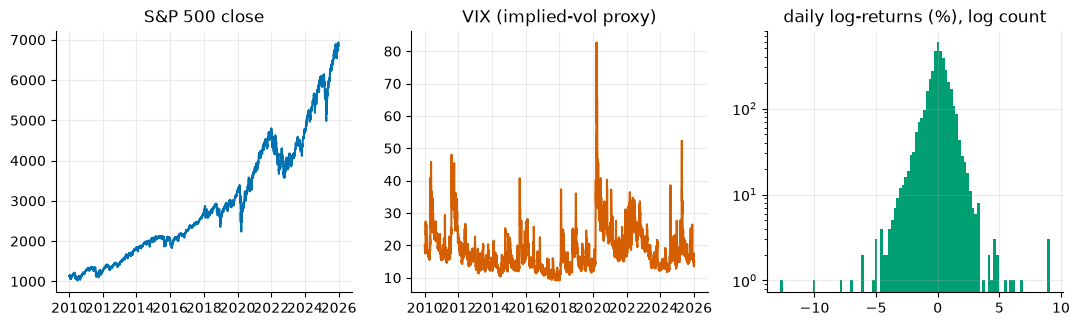

CHECK daily return sd (%): 1.094 | excess kurtosis: 13.57


In [3]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
ax[0].plot(df.index, df['spx'], color=PAL[0]); ax[0].set_title('S&P 500 close')
ax[1].plot(df.index, df['vix'], color=PAL[3]); ax[1].set_title('VIX (implied-vol proxy)')
r = np.log(df['spx']).diff().dropna(); ax[2].hist(r * 100, bins=100, color=PAL[2]); ax[2].set_yscale('log'); ax[2].set_title('daily log-returns (%), log count')
show(fig)
print('CHECK daily return sd (%):', round(r.std() * 100, 3), '| excess kurtosis:', round(float(r.kurt()), 2))

## 2. During: how rough is the VIX?
The scaling estimator of notebook 01 applied to log VIX. Because VIX is a smoothed (30-day) proxy, an estimate well above 0.1 is expected and does **not** contradict a small H for instantaneous volatility. A simulated calibration applies the same estimator to daily-sampled model variance and to its 21-day average.

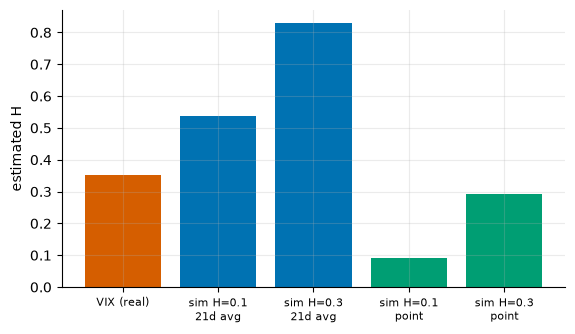

CHECK H(log VIX) = 0.352 | simulated 21d-average proxy: {0.1: 0.538, 0.3: 0.83}
CHECK averaging raises the estimate above the point-sampled value: True


In [4]:
x = np.log(df['vix'].values)
h_vix, _ = estimate_hurst(x, lags=range(1, 21))
cal = {}
for H in (0.1, 0.3):
    _r = simulate_rbergomi(60, 252 * 8, 8.0, H, 1.9, -0.7, 0.235**2, rng=np.random.default_rng(5)); _, V = _r['S'], _r['V']
    pt = float(np.mean([estimate_hurst(np.log(v), lags=range(1, 21))[0] for v in V]))
    w = 21; cs = np.cumsum(V, axis=1); avg = (cs[:, w:] - cs[:, :-w]) / w
    av = float(np.mean([estimate_hurst(0.5 * np.log(v), lags=range(1, 21))[0] for v in avg]))
    cal[H] = (pt, av)
fig, ax = plt.subplots(figsize=(6.5, 3.6))
lab = ['VIX (real)'] + [f'sim H={H}\n21d avg' for H in cal] + [f'sim H={H}\npoint' for H in cal]
val = [float(h_vix)] + [cal[H][1] for H in cal] + [cal[H][0] for H in cal]
ax.bar(range(len(val)), val, color=[PAL[3]] + [PAL[0]] * 2 + [PAL[2]] * 2); ax.set_xticks(range(len(val))); ax.set_xticklabels(lab, fontsize=8)
ax.set_ylabel('estimated H'); show(fig)
print('CHECK H(log VIX) =', round(float(h_vix), 3), '| simulated 21d-average proxy:', {H: round(v[1], 3) for H, v in cal.items()})
print('CHECK averaging raises the estimate above the point-sampled value:', all(v[1] > v[0] for v in cal.values()))

## 3. After: hedge replay on real S&P 500 windows
Every 5th trading day starts a 30-day at-the-money (strike = start price) short call, hedged daily with each methodology under 10 bp proportional costs. Learned hedgers come from a simulated-only training run (same code as notebook 02).

In [5]:
result = run_comparison(CFG)
losses = {a: result['test_losses'][a] for a in ARMS}
rows = []
for a in ARMS:
    per_seed = [cvar_tail_mean(losses[a][k], 0.95) for k in range(CFG['n_seeds'])]
    rows.append(dict(arm=a, cvar95_mean=np.mean(per_seed), cvar95_sd=np.std(per_seed, ddof=1) if len(per_seed) > 1 else 0.0,
                     mean_loss=losses[a].mean()))
tab = pd.DataFrame(rows).set_index('arm')
print('CHECK shared test paths hash:', result['test_paths_sha256'][:12], '| config hash:', result['config_hash'][:12])
print('CHECK all arms leakage-checked:', all(result['leakage_checked'].values()))
print(tab.round(5).to_string())


CHECK shared test paths hash: 387734c9c3c5 | config hash: 747a5fcc6815
CHECK all arms leakage-checked: True


          cvar95_mean  cvar95_sd  mean_loss
arm                                        
bs_delta      0.05651    0.00000    0.02665
leland        0.05631    0.00000    0.02665
ww_band       0.05638    0.00000    0.02597
ffn           0.09382    0.01151    0.02650
gru           0.08700    0.00496    0.02602
sig2          0.08913    0.00254    0.02615


CHECK windows: 799 | first 2010-01-04 last 2025-11-12
           cvar95     mean       sd
bs_delta  0.05114  0.02310  0.00973
leland    0.05102  0.02309  0.00975
ww_band   0.04826  0.02279  0.01074
ffn       0.07733  0.02339  0.01952
gru       0.07180  0.02229  0.01827
sig2      0.07841  0.02345  0.02020


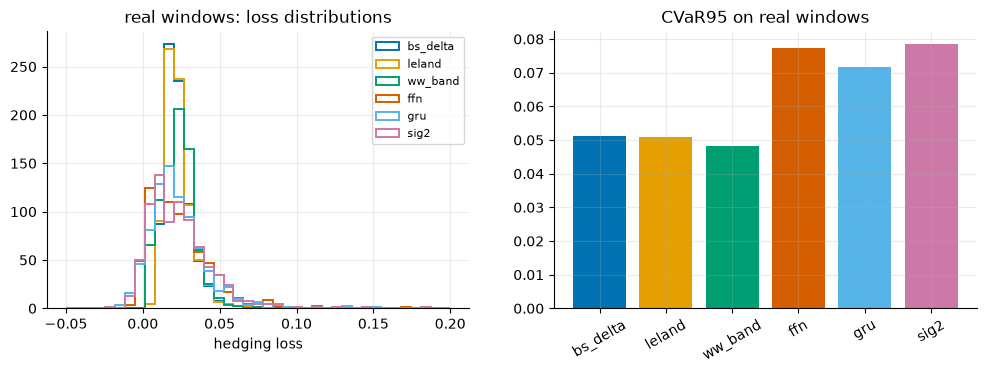

In [6]:
px = df['spx'].values
starts = np.arange(0, len(px) - 31, 5)
W = np.stack([px[s:s + 31] / px[s] for s in starts])
c = CFG['cost_bp'] * 1e-4
real = {}
for a in ARMS:
    pos = result['policies'][a][0](W)
    real[a] = -hedging_pnl(W, np.asarray(pos), strike=1.0, cost=c).pnl
rr = pd.DataFrame({a: [cvar_tail_mean(real[a], .95), real[a].mean(), real[a].std()] for a in ARMS}, index=['cvar95', 'mean', 'sd']).T
print('CHECK windows:', len(W), '| first', df.index[starts[0]].date(), 'last', df.index[starts[-1]].date())
print(rr.round(5).to_string())
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
bins = np.linspace(-0.05, 0.2, 40)
for i, a in enumerate(ARMS): ax[0].hist(real[a], bins=bins, histtype='step', color=PAL[i], label=a, lw=1.4)
ax[0].legend(fontsize=8); ax[0].set_xlabel('hedging loss'); ax[0].set_title('real windows: loss distributions')
ax[1].bar(range(len(ARMS)), rr['cvar95'], color=PAL[:len(ARMS)]); ax[1].set_xticks(range(len(ARMS))); ax[1].set_xticklabels(ARMS, rotation=30)
ax[1].set_title('CVaR95 on real windows'); show(fig)

In [7]:
from rough_hedge.stats import paired_bootstrap
out = []
for a in ARMS[1:]:
    b = paired_bootstrap(real[a], real['bs_delta'], n_boot=1000, seed=7)
    out.append(dict(arm=a, diff_vs_bs=b.estimate, lo=b.lo, hi=b.hi, p=b.pvalue))
cmp = pd.DataFrame(out).set_index('arm'); cmp['p_holm'] = holm(cmp['p'].tolist())[0]
print(cmp.round(5).to_string())
print('NOTE windows overlap by 25 of 30 days, so the effective sample is smaller than the window count; intervals are optimistic.')

         diff_vs_bs       lo       hi        p   p_holm
arm                                                    
leland     -0.00012 -0.00033  0.00006  0.17582  0.23976
ww_band    -0.00288 -0.00667  0.00067  0.11988  0.23976
ffn         0.02619  0.01701  0.03618  0.00200  0.00999
gru         0.02067  0.01193  0.03000  0.00200  0.00999
sig2        0.02727  0.01777  0.03770  0.00200  0.00999
NOTE windows overlap by 25 of 30 days, so the effective sample is smaller than the window count; intervals are optimistic.


## 4. Limits and reading
* VIX is a proxy; the roughness estimate describes a smoothed implied-volatility level and is not an estimate of the model H.
* Hedge replay uses realised price paths, assumed costs, and a grid of 30 trading days treated as the model horizon; the models were trained on 30/365 years, so there is a time-scale mismatch.
* Overlapping windows and a single historical path make the comparison indicative only; any difference to Black-Scholes delta is reported as measured, whichever sign it has.